# 10 — Embeddings v2: Force-binned analogy drift

**Hypothesis (from v1):** `force` is the analogy carrier in static lens space.
**Question:** does force *also* anchor analogies through Syracuse iteration?

**Test:** generate ~50 random Syracuse-shift quads `(a, T_syr(a), c, T_syr(c))`.
For each quad, compute mean force across all four concepts and use it as a
"confidence" score. Bin quads by mean force into tertiles. For each quad,
compute the drift curve `cos(Phi(b) - Phi(a), Phi(T^k b) - Phi(T^k a))` over
k = 0..8. Plot per-bin mean drift curves with +/-1 SE bands.

**Prediction:** high-force tertile preserves cosine ~ 1 longer than low-force.

**Falsifiers:**
- All bins overlap -> force is a *static* lens but not a temporal anchor.
- Low-force decays *slower* than high-force -> "confidence" reading is wrong.

Either way: information.


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, Phi, T_syracuse
from collatz.embeddings.lenses import force
from collatz.embeddings.distance import cosine
from collatz.embeddings.iteration import _syr_step


## 1. Generate quads spanning a force range

We pull odd integers from a wide range so we get varied force values.
Each quad is `(a, T_syr(a), c, T_syr(c))` where a and c are independent triples.


In [2]:
random.seed(7)
N_QUADS = 60

def random_triple(lo, hi):
    return tuple(random.randrange(lo, hi) | 1 for _ in range(3))  # force odd

def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

quads = []
for i in range(N_QUADS):
    # vary scale of integers to get force diversity
    scale = random.choice([10, 50, 200, 1000, 5000])
    a = Concept(f"a{i}", random_triple(2, scale))
    c = Concept(f"c{i}", random_triple(2, scale))
    b = shift(a)
    d = shift(c)
    quads.append((a, b, c, d))

# mean force across the 4 concepts (12 components total) is the quad's "confidence"
quad_force = []
for a, b, c, d in quads:
    fs = [force(n) for con in (a, b, c, d) for n in con.vec]
    quad_force.append(float(np.mean(fs)))

print(f"force range: min={min(quad_force):.1f}, max={max(quad_force):.1f}, median={np.median(quad_force):.1f}")
print(f"sample force values: {sorted(quad_force)[:5]} ... {sorted(quad_force)[-5:]}")


force range: min=2.7, max=24.2, median=5.4
sample force values: [2.6666666666666665, 2.6666666666666665, 2.75, 3.0833333333333335, 3.0833333333333335] ... [12.0, 12.416666666666666, 14.333333333333334, 14.833333333333334, 24.166666666666668]


## 2. Compute drift curves


In [3]:
def iterate(c: Concept, k: int) -> Concept:
    for _ in range(k):
        c = T_syracuse(c)
    return c

K = 8
drift_curves = np.zeros((N_QUADS, K + 1))
for q_idx, (a, b, c, d) in enumerate(quads):
    base_diff = Phi(b) - Phi(a)
    for k in range(K + 1):
        ak = iterate(a, k)
        bk = iterate(b, k)
        diff_k = Phi(bk) - Phi(ak)
        drift_curves[q_idx, k] = cosine(diff_k, base_diff)

print(f"drift curves shape: {drift_curves.shape}")
print(f"mean drift at k=0: {drift_curves[:, 0].mean():.3f}  (sanity: should be 1.0)")
print(f"mean drift at k={K}: {drift_curves[:, K].mean():.3f}")


drift curves shape: (60, 9)
mean drift at k=0: 1.000  (sanity: should be 1.0)
mean drift at k=8: 0.079


## 3. Bin by force tertile and plot


bin sizes: low=20, mid=20, high=20


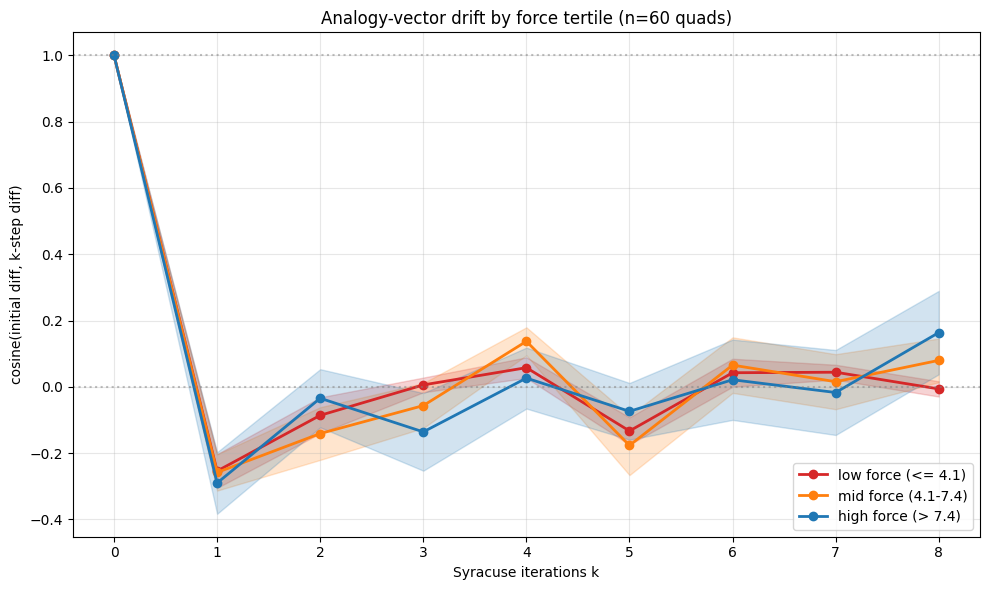

In [4]:
quad_force = np.array(quad_force)
t1, t2 = np.percentile(quad_force, [33.33, 66.67])
bins = np.digitize(quad_force, [t1, t2])  # 0 = low, 1 = mid, 2 = high

bin_labels = {0: f"low force (<= {t1:.1f})", 1: f"mid force ({t1:.1f}-{t2:.1f})", 2: f"high force (> {t2:.1f})"}
bin_colors = {0: "tab:red", 1: "tab:orange", 2: "tab:blue"}

print(f"bin sizes: low={int((bins==0).sum())}, mid={int((bins==1).sum())}, high={int((bins==2).sum())}")

fig, ax = plt.subplots(figsize=(10, 6))
for b_idx in [0, 1, 2]:
    mask = bins == b_idx
    if mask.sum() == 0: continue
    curves = drift_curves[mask]
    mean = curves.mean(axis=0)
    se = curves.std(axis=0) / np.sqrt(curves.shape[0])
    ks = np.arange(K + 1)
    ax.plot(ks, mean, marker="o", color=bin_colors[b_idx], label=bin_labels[b_idx], linewidth=2)
    ax.fill_between(ks, mean - se, mean + se, color=bin_colors[b_idx], alpha=0.2)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.axhline(1, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Syracuse iterations k")
ax.set_ylabel("cosine(initial diff, k-step diff)")
ax.set_title(f"Analogy-vector drift by force tertile (n={N_QUADS} quads)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Statistical summary


In [5]:
print(f"{'k':>3} {'low mean':>12} {'mid mean':>12} {'high mean':>12} {'high - low':>12}")
print("-" * 55)
for k in range(K + 1):
    low = drift_curves[bins == 0, k].mean()
    mid = drift_curves[bins == 1, k].mean()
    high = drift_curves[bins == 2, k].mean()
    print(f"{k:>3} {low:>12.3f} {mid:>12.3f} {high:>12.3f} {high - low:>+12.3f}")


  k     low mean     mid mean    high mean   high - low
-------------------------------------------------------
  0        1.000        1.000        1.000       +0.000
  1       -0.254       -0.258       -0.290       -0.036
  2       -0.086       -0.141       -0.034       +0.052
  3        0.006       -0.057       -0.136       -0.142
  4        0.058        0.137        0.026       -0.031
  5       -0.133       -0.177       -0.074       +0.059
  6        0.043        0.065        0.021       -0.021
  7        0.044        0.015       -0.017       -0.061
  8       -0.006        0.080        0.164       +0.170


## 5. Verdict template

Read off the table above:

- If `high - low` is **consistently positive and grows with k**: hypothesis confirmed.
  Force anchors the analogy through iteration; v1's "epistemic confidence"
  interpretation has dynamic evidence.
- If `high - low` **fluctuates around 0**: force is static-only. It picks the
  analogy out at k=0 but doesn't help it survive iteration. Different finding,
  still useful — shifts attention to *which* anchoring lens (sector? slope_log?)
  carries the time component.
- If `high - low` is **negative** (low force decays slower): seriously surprising;
  would mean compact / well-determined concepts dissolve faster than diffuse ones.
  Force interpretation needs an inversion.
